In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from msfm.utils import files, parameters

from msfm.utils.prior import in_grid_prior
from msi.utils.sbi_utils import torch_in_grid_prior

24-01-11 07:48:56   imports.py INF   Setting up healpy to run on 256 CPUs 


In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
params = ["Om", "s8"]
prior_intervals = parameters.get_prior_intervals(params)

rng = np.random.default_rng()
rands = rng.uniform(low=prior_intervals[:,0], high=prior_intervals[:,1], size=(1000, 2))

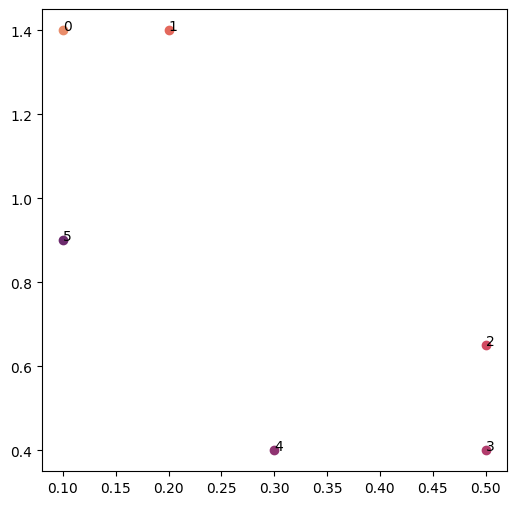

In [4]:
Om_s8_border_points = conf["analysis"]["grid"]["priors"]["Om_s8_border_points"]

fig, ax = plt.subplots(figsize=(6,6))

colors = sns.color_palette("flare", len(Om_s8_border_points))
for i, point in enumerate(Om_s8_border_points):
    ax.scatter(point[0], point[1], color=colors[i])
    ax.text(point[0], point[1], i)

# original numpy version

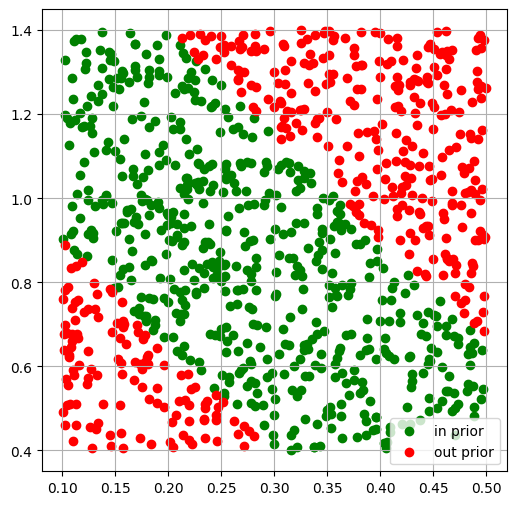

In [5]:
prior_mask = in_grid_prior(rands, conf, params)

in_prior = rands[prior_mask]
out_prior = rands[~prior_mask]

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(in_prior[:,0], in_prior[:,1], color="green", label="in prior")
ax.scatter(out_prior[:,0], out_prior[:,1], color="red", label="out prior")

ax.legend()
ax.grid(True)

# pytorch version

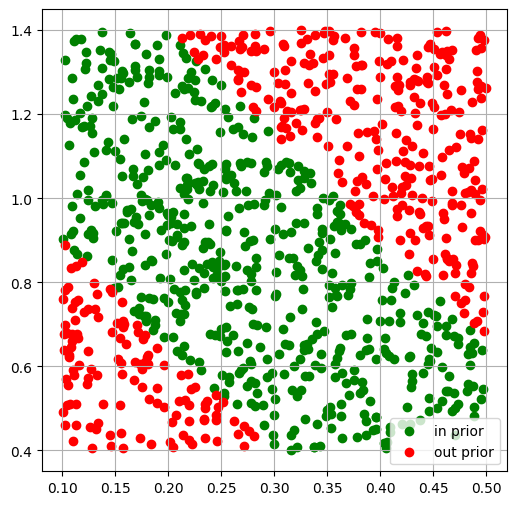

In [6]:
# device = "cpu"
device = "cuda"

torch_rands = torch.tensor(rands, dtype=torch.float32, device=device)

torch_prior_mask = torch_in_grid_prior(torch_rands, conf, params, device)
torch_prior_mask = torch_prior_mask.cpu().numpy()

torch_in_prior = rands[torch_prior_mask]
torch_out_prior = rands[~torch_prior_mask]

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(torch_in_prior[:,0], torch_in_prior[:,1], color="green", label="in prior")
ax.scatter(torch_out_prior[:,0], torch_out_prior[:,1], color="red", label="out prior")

ax.legend()
ax.grid(True)

In [7]:
np.all(torch_in_prior == in_prior)

True